# 3.0 Model training - Ridge


## Imports


In [1]:
import numpy as np
import pandas as pd
import joblib
import json
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_log_error

from recruit_restaurant_visitor_forecasting.config import (
    AIR_RESTAURANT_ID_COL,
    MODELS_DIR,
    VISIT_DATE_COL,
    DAY_OF_WEEK_COL,
    VISITORS_NBR_COL,
    CITY_COL,
)
from recruit_restaurant_visitor_forecasting.dataset import read_csv, DataDir, save_csv
from recruit_restaurant_visitor_forecasting.modeling.train import (
    load_data,
    prepare_features,
    ridge_gridsearch,
    train_test_split_by_date,
)
from recruit_restaurant_visitor_forecasting.plots import plot_daily_pred, plot_features_target_corr
from recruit_restaurant_visitor_forecasting.utils import merge_daily_pred, get_format
from recruit_restaurant_visitor_forecasting.modeling.predict import recursive_predict

2025-12-27 17:36:38.187 | INFO     | recruit_restaurant_visitor_forecasting.config:<module>:12 - PROJ_ROOT path is: D:\mentoring_program


In [2]:
ALPHA = 1000
CV_SPLITS = 5
TEST_SIZE = 0.2
DROP_COLUMNS = [AIR_RESTAURANT_ID_COL, VISIT_DATE_COL, VISITORS_NBR_COL, DAY_OF_WEEK_COL, CITY_COL]

MODEL_PATH = MODELS_DIR / "ridge_model.pkl"

## Load and prepare

In [3]:
features, labels = load_data()
print(f"Features shape: {features.shape}")
print(f"Labels shape: {labels.shape}")

Features shape: (271221, 50)
Labels shape: (271221,)


In [4]:
original_index = features.index.copy()
features = prepare_features(features)

labels = labels.loc[features.index].reset_index(drop=True)
features = features.reset_index(drop=True)

In [5]:
X = features
y = labels

In [6]:
X_train, X_test, y_train, y_test = train_test_split_by_date(
    X, y, date_col=VISIT_DATE_COL, test_size=TEST_SIZE
)

train_dates = X_train[VISIT_DATE_COL]
test_dates = X_test[VISIT_DATE_COL]

print(f"Train set dates: {train_dates.min()} to {train_dates.max()}")
print(f"Test set dates: {test_dates.min()} to {test_dates.max()}")

Train set dates: 2016-02-01 00:00:00 to 2017-01-22 00:00:00
Test set dates: 2017-01-23 00:00:00 to 2017-04-22 00:00:00


### Correlation of predictors and target

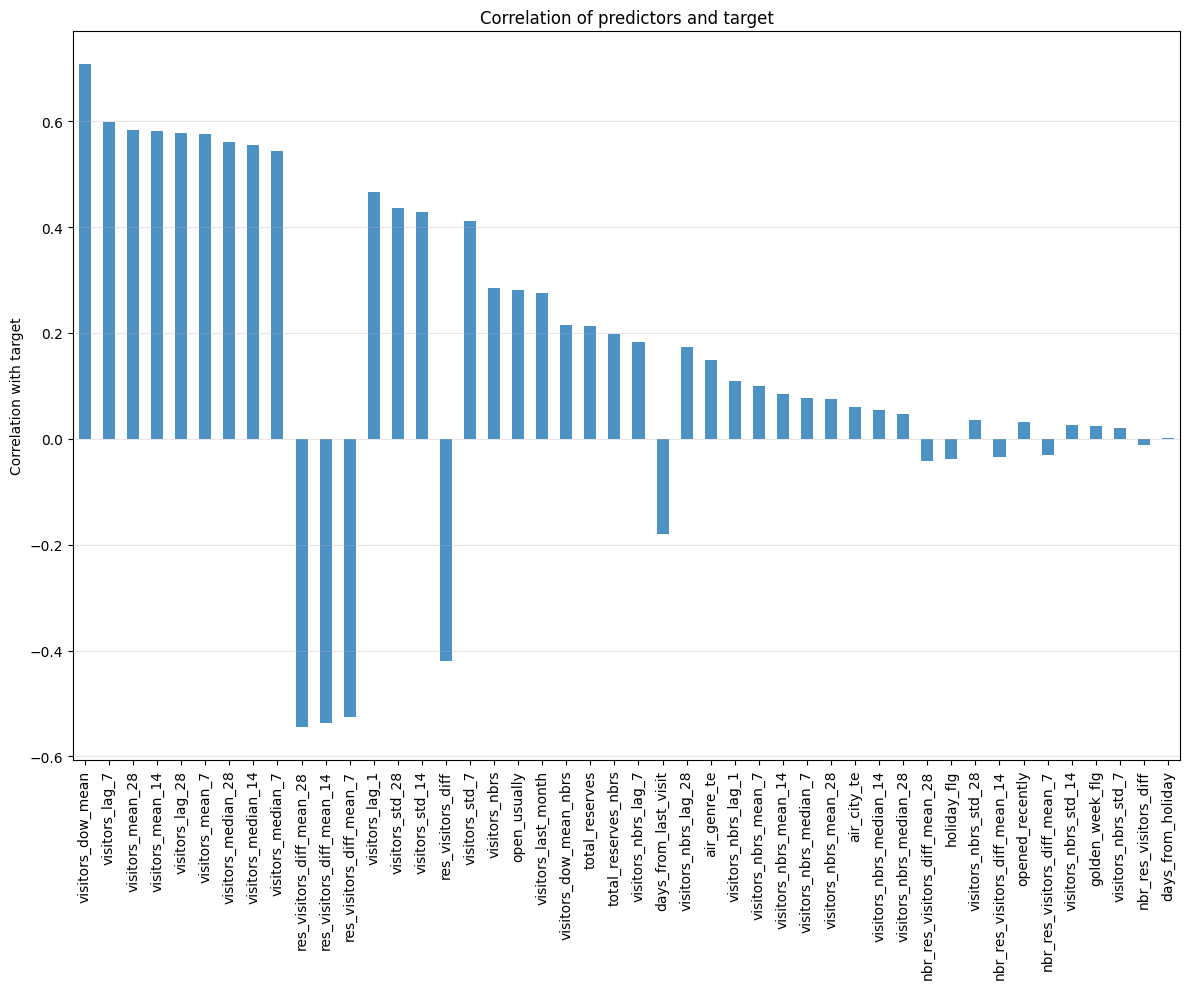

In [7]:
plot_features_target_corr(X_train, y_train)

## Training


In [9]:
grid_search = ridge_gridsearch(verbose=2, n_jobs=-1, drop_features=DROP_COLUMNS)
grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)
print("Best score:", grid_search.best_score_)

Fitting 5 folds for each of 720 candidates, totalling 3600 fits
Best parameters: {'ridge__alpha': np.float64(10000.0), 'selector__estimator__alpha': np.float64(1.0), 'selector__estimator__max_iter': 500, 'selector__threshold': 'median'}
Best score: -11.273260153628026


In [10]:
pd.DataFrame(grid_search.cv_results_).sort_values("rank_test_score").head()

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_ridge__alpha,param_selector__estimator__alpha,param_selector__estimator__max_iter,param_selector__threshold,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
594,1.679546,0.649520,0.094736,0.015180,10000.0,1.0,500,median,"{'ridge__alpha': 10000.0, 'selector__estimator...",-10.93011,-11.226717,-10.424759,-10.777347,-13.007368,-11.27326,0.904758,1
612,0.766387,0.178877,0.079599,0.005982,10000.0,10.0,500,median,"{'ridge__alpha': 10000.0, 'selector__estimator...",-10.93011,-11.226717,-10.424759,-10.777347,-13.007368,-11.27326,0.904758,1
600,1.325053,0.430530,0.103685,0.018073,10000.0,1.0,1000,median,"{'ridge__alpha': 10000.0, 'selector__estimator...",-10.93011,-11.226717,-10.424759,-10.777347,-13.007368,-11.27326,0.904758,1
606,1.311398,0.369995,0.097788,0.015483,10000.0,1.0,2000,median,"{'ridge__alpha': 10000.0, 'selector__estimator...",-10.93011,-11.226717,-10.424759,-10.777347,-13.007368,-11.27326,0.904758,1
624,0.551853,0.159847,0.061401,0.008783,10000.0,10.0,2000,median,"{'ridge__alpha': 10000.0, 'selector__estimator...",-10.93011,-11.226717,-10.424759,-10.777347,-13.007368,-11.27326,0.904758,1


In [11]:
model = grid_search.best_estimator_
X_dropped = X.drop(columns=DROP_COLUMNS)
sel = model.named_steps.get("selector", None)
support = sel.get_support()
selected_cols = X_dropped.columns[support]

print(f"Selected features: {list(selected_cols)}"
      f"\nCount of selected features: {len(selected_cols)}")

Selected features: ['opened_recently', 'holiday_flg', 'days_from_holiday', 'golden_week_flg', 'open_usually', 'days_from_last_visit', 'air_city_te', 'air_genre_te', 'total_reserves', 'total_reserves_nbrs', 'visitors_mean_7', 'visitors_median_7', 'visitors_std_7', 'visitors_mean_14', 'visitors_median_14', 'visitors_std_14', 'visitors_mean_28', 'visitors_median_28', 'visitors_std_28', 'visitors_nbrs_mean_7', 'visitors_nbrs_median_7', 'visitors_nbrs_std_7', 'visitors_nbrs_mean_14', 'visitors_nbrs_median_14', 'visitors_nbrs_std_14', 'visitors_nbrs_mean_28', 'visitors_nbrs_median_28', 'visitors_nbrs_std_28', 'visitors_last_month', 'visitors_lag_1', 'visitors_lag_7', 'visitors_lag_28', 'visitors_nbrs_lag_1', 'visitors_nbrs_lag_7', 'visitors_nbrs_lag_28', 'visitors_dow_mean', 'visitors_dow_mean_nbrs', 'res_visitors_diff', 'res_visitors_diff_mean_7', 'res_visitors_diff_mean_14', 'res_visitors_diff_mean_28', 'nbr_res_visitors_diff', 'nbr_res_visitors_diff_mean_7', 'nbr_res_visitors_diff_mean_14

In [12]:
y_train_pred = model.predict(X_train)
y_train_pred = np.maximum(y_train_pred, 0)

train_rmsle = np.sqrt(mean_squared_log_error(y_train, y_train_pred))
train_mae = mean_absolute_error(y_train, y_train_pred)
train_r2 = r2_score(y_train, y_train_pred)

print(f"Train set metrics:")
print(f"RMSLE: {train_rmsle:.4f}")
print(f"MAE:  {train_mae:.4f}")
print(f"R2:   {train_r2:.4f}")

Train set metrics:
RMSLE: 0.9291
MAE:  7.2882
R2:   0.5642


In [ ]:
y_test_pred, temp_features = recursive_predict(
    model,
    X_test,
    X_train,
    y_train,
    drop_cols=DROP_COLUMNS,
)

Predicting recursively:   0%|          | 0/90 [00:00<?, ?it/s]D:\mentoring_program\recruit_restaurant_visitor_forecasting\modeling\predict.py:148: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[1.56784393e+01 9.68103211e+00 8.72986944e+00 3.66263322e+00
 4.17158339e+00 1.70179532e+01 1.48667098e+01 3.08049436e+01
 3.05800247e+01 8.34255712e+00 2.06077152e+01 3.21340103e+00
 1.91410698e+01 3.23102208e+01 1.22688340e+01 8.13380364e+00
 2.43633013e-01 6.61973052e+00 1.93962731e+00 3.08753470e+01
 1.97889748e+01 3.53449389e+01 7.66429018e+00 1.02027423e+01
 1.01818271e+01 1.51658420e+01 2.75500132e+00 1.17802286e+01
 8.80484089e+00 2.45925220e+01 0.00000000e+00 4.48859044e+01
 2.41476061e+01 6.74174151e+00 0.00000000e+00 2.92605474e+01
 9.96863239e+00 1.91899126e+00 1.03425707e+01 1.05505994e+01
 9.58922244e-01 8.46040251e+00 1.61283593e+01 5.33228459e+00
 0.00000000e+00 1.43415329e+01 9.44626601e+00 3.76489

In [9]:
test_rmsle = np.sqrt(mean_squared_log_error(y_test, y_test_pred))
test_mae = mean_absolute_error(y_test, y_test_pred)
test_r2 = r2_score(y_test, y_test_pred)
print(f"\nTest set metrics:")
print(f"RMSLE: {test_rmsle:.4f}")
print(f"MAE:  {test_mae:.4f}")
print(f"R2:   {test_r2:.4f}")


Test set metrics:
RMSLE: 0.8789
MAE:  7.5523
R2:   0.5370


## Graphs

### Visitors per day: actual vs predicted

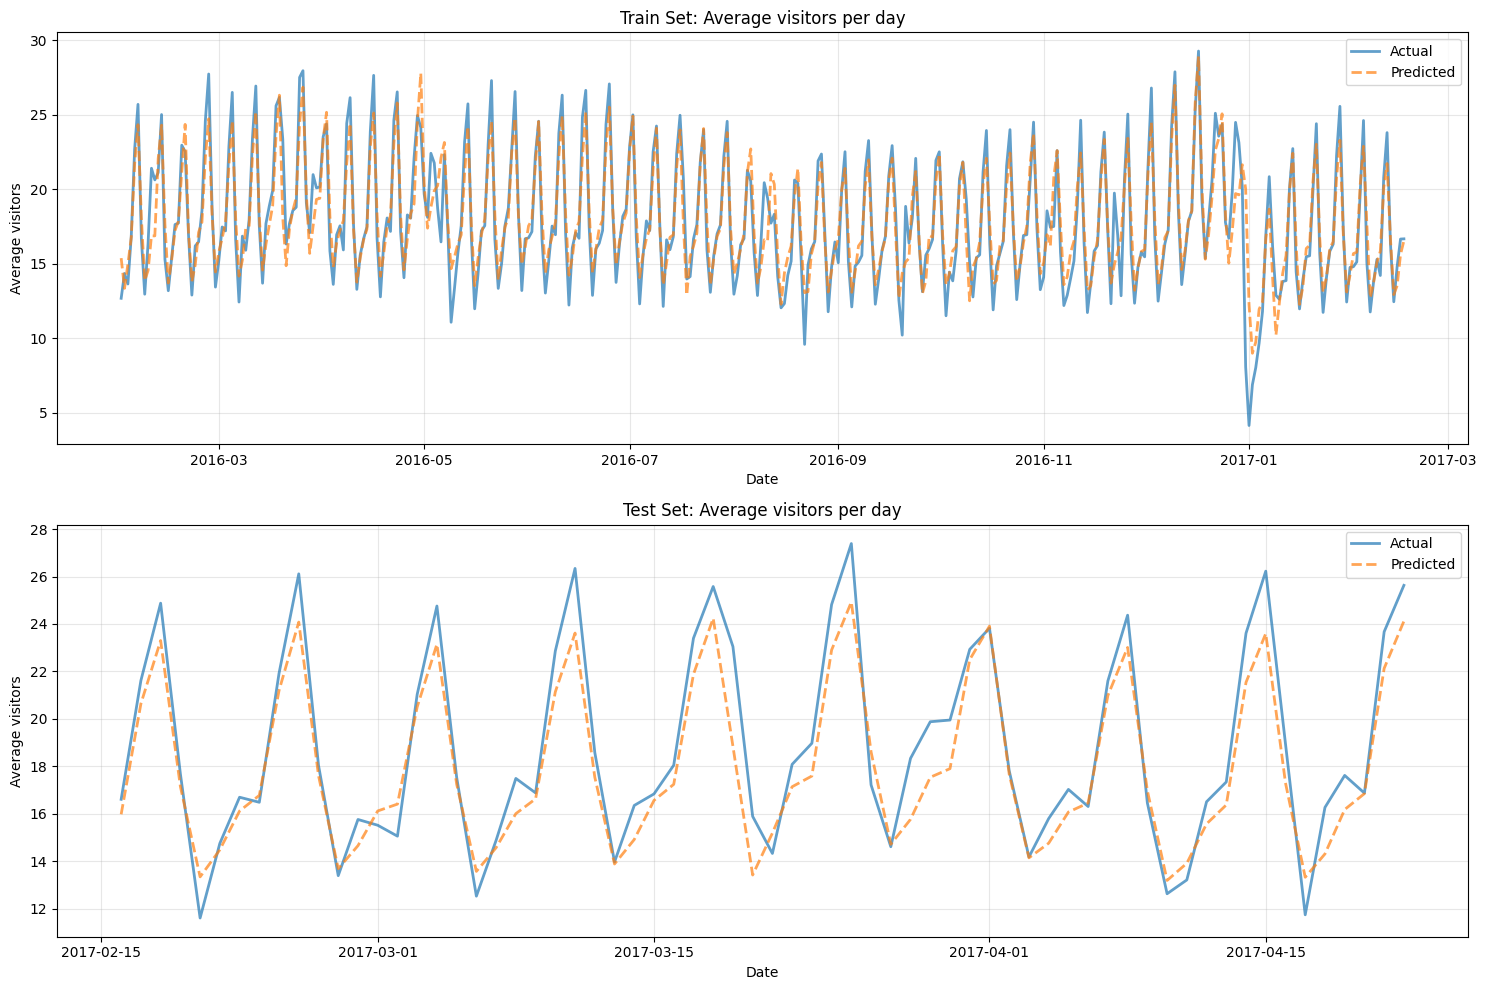

In [12]:
train_daily = merge_daily_pred(train_dates, y_train, y_train_pred)
test_daily = merge_daily_pred(test_dates, y_test, y_test_pred)

fig, axes = plt.subplots(2, 1, figsize=(15, 10))

plot_daily_pred(train_daily, axes[0], train=True)
plot_daily_pred(test_daily, axes[1], train=False)

plt.tight_layout()
plt.show()

## Testing on future data

In [22]:
model = joblib.load(MODEL_PATH)

In [18]:
test_features = read_csv("test_features.csv", DataDir.PROCESSED)
test_features = prepare_features(test_features)

In [19]:
test_labels, temp_features = recursive_predict(
    model,
    test_features,
    X,
    y,
    drop_cols=DROP_COLUMNS,
)

Predicting recursively:   0%|          | 0/39 [00:00<?, ?it/s]C:\Users\lymuthien\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
D:\mentoring_program\recruit_restaurant_visitor_forecasting\modeling\predict.py:148: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[3.18642449e+00 0.00000000e+00 1.04921221e+01 6.29277827e+00
 2.39866476e+01 2.60008095e+01 2.68210140e+01 7.26226667e+00
 3.77612998e+01 2.29272401e+00 2.50327210e+01 5.11087575e+00
 2.97733842e+01 4.67489879e+01 2.47574984e+01 5.99309922e+00
 1.53579164e+01 1.21390260e+01 2.47319996e+01 4.80240510e+01
 7.32583465e+00 1.62913510e+01 1.51298506e+01 1.79621829e+01
 3.17202433e-01 2.81865974e+01 1.34270759e+01 1.98535950e+01
 3.28643935e-02 1.50979724e+01 2.11921016e+01 8.75433145e+00
 2.046548

In [20]:
labels_format = get_format(test_features, test_labels)
save_csv(labels_format, "test_labels.csv", DataDir.PROCESSED)

## Saving model

In [ ]:
joblib.dump(model, MODEL_PATH)
cv_results = pd.DataFrame(grid_search.cv_results_).sort_values("rank_test_score")

params_to_save = {
    "cv result": cv_results.sort_values(["rank_test_score"]).iloc[0].to_dict(),
    "selected_features": list(selected_cols),
    "n_features": len(selected_cols)
}

params_path = MODELS_DIR / "ridge_model_params.json"
with open(params_path, 'w', encoding='utf-8') as f:
    json.dump(params_to_save, f, indent=2, ensure_ascii=False)